In [1]:
import time,json,os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from sklearn.ensemble import BaggingClassifier
from common import preprocess
import seaborn as sns
from sklearn.svm import SVC
import joblib
from warnings import filterwarnings
filterwarnings("ignore") 
np.set_printoptions(suppress=True)
pd.set_option('display.float_format',lambda x : '%.4f' % x)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)
plt.style.use({'figure.figsize':(12, 4)})

In [2]:
def show_heatmap(df):
    plt.style.use({'figure.figsize':(12, 6)})
    plt.ticklabel_format(style='plain',axis='both')
    cmap = sns.cubehelix_palette(start = 1, rot = 3, gamma=0.8, as_cmap = True)
    return sns.heatmap(df, cmap = cmap, linewidths = 0.05,annot=False, fmt="g",annot_kws={"fontsize":16})
    #plt.xticks(rotation=60)
    #plt.yticks(rotation=60)

In [3]:
class CJAnalyse:
    
    def __init__(self, model_name):
        self.df_similarity = pd.read_csv("/data/paper2/analyse/similarity.csv",index_col=0)
        self.df_model = pd.read_csv("/data/paper2/analyse/%s.csv"%model_name,index_col=0)
        self.filter_useless_fields()
        
    def get_similar(self, d1, d2):
        mask = (self.df_similarity['D1'] == "%s"%d1) & (self.df_similarity['D2'] == d2)
        ret = {}
        for D in self.df_similarity.keys():
            if D in ['D1','D2']:
                continue
            ret[D] = self.df_similarity[mask].iloc[0][D]
        return ret
    
    def filter_useless_fields(self):
        df_m = self.df_model.copy( deep = True )
        del df_m['confusion_matrix']
        del df_m['roc_curve']
        del df_m['mcc']
        del df_m['log_loss']
        del df_m['fbeta_score']
        self.df_model = df_m
        
    def Merge(self):
        all_data = []
        for item in json.loads(self.df_model.to_json(orient="records")):
            tmp = item
            tmp["train"] = item["train"]
            tmp["valid"] = item["valid"]
            similar = self.get_similar(item["train"], item['valid'])
            for s in similar:
                tmp[s] = similar[s]
            all_data.append(tmp)
        return pd.DataFrame(all_data)
    
    #pearsonr,spearmanr or kendalltau
    def Correlation(self,df, kind = "pearsonr"):
        df_merged = df.copy( deep= True )
        all_data = []
        for score in self.df_model.keys():
            if score in ['model', 'train', 'valid']:
                continue
            s1 = df_merged[score]
            metric_value = {}
            metric_value['score'] = score
            metric_list = self.df_similarity.keys()
            for metric in metric_list:
                if metric in ['D1','D2']:
                    continue
                s2 = df_merged[metric]
                if kind == 'pearsonr':
                    metric_value[metric] = scipy.stats.pearsonr(s1,s2)[0]
                if kind == 'spearmanr':
                    metric_value[metric] = scipy.stats.spearmanr(s1,s2)[0]
                if kind == 'kendalltau':
                    metric_value[metric] = scipy.stats.kendalltau(s1,s2)[0]
                metric_value[metric] = abs(metric_value[metric])
            all_data.append(metric_value)

        df_all = pd.DataFrame(all_data)
        df_all.set_index("score", inplace = True, drop = True)
        return df_all #.reset_index()

In [4]:
test = CJAnalyse("cnn")
df_all = test.Merge()

# Correlations for each base set

In [6]:
df_base_set_corr = pd.DataFrame()
for train_set in ["0-*","1-*","2-*","3-*"]:
    mask = df_all.train.str.contains(r'%s'%train_set)
    df_test = df_all[mask]
    df_base_set_corr[train_set] = test.Correlation(df_test).mean()
display(df_base_set_corr.T.mean())
df_base_set_corr

Cosine      0.6321
Pearson     0.6319
Euclidean   0.6565
EDM         0.8642
KS          0.4912
Manhattan   0.7187
Minkowski   0.6053
Jaccard     0.1222
Entropy     0.1487
dtype: float64

,0-*,1-*,2-*,3-*
Cosine,0.6169,0.5166,0.6759,0.7190
Pearson,0.6166,0.5163,0.6758,0.7189
Euclidean,0.6552,0.5527,0.6865,0.7314
EDM,0.8594,0.8325,0.8648,0.9001
KS,0.5171,0.4159,0.4971,0.5349
Manhattan,0.7037,0.5963,0.7640,0.8106
Minkowski,0.6128,0.5077,0.6284,0.6722
Jaccard,0.1253,0.1281,0.1145,0.1210
Entropy,0.1475,0.1148,0.1272,0.2054


Text(0.5, 1.0, 'Correlation between Base sample and Distance')

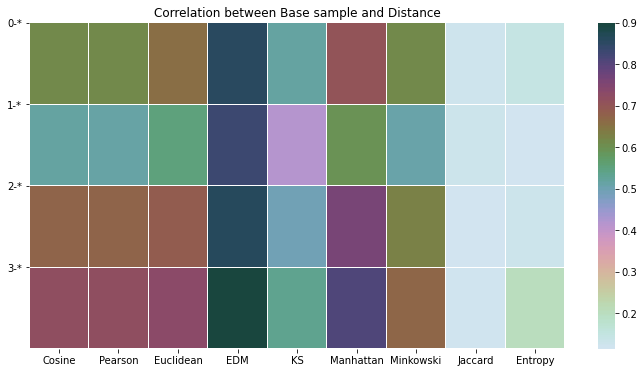

In [7]:
ax = show_heatmap(df_base_set_corr.T)
ticks = ax.set_yticks(range(len(df_base_set_corr.T.index))) # 设置刻度
labels = ax.set_yticklabels(df_base_set_corr.T.index,rotation = 0 ) # 设置刻度标签
ax.set_title("Correlation between Base sample and Distance")

Text(0.5, 1.0, 'Correlation between Base sample and Distance')

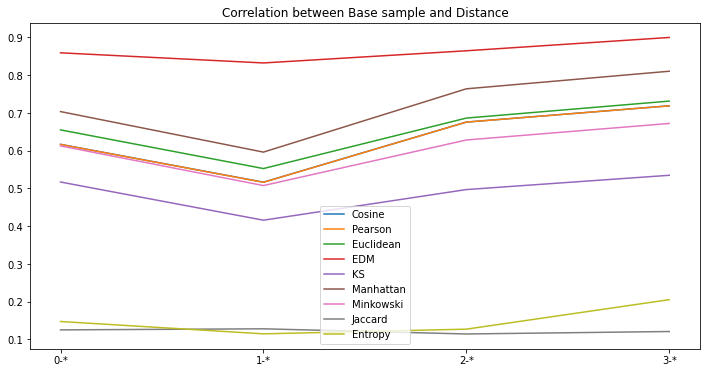

In [8]:
ax = df_base_set_corr.T.plot(kind='line')
ticks = ax.set_xticks(range(len(df_base_set_corr.T.index))) # 设置刻度
labels = ax.set_xticklabels(df_base_set_corr.T.index,rotation = 0 ) # 设置刻度标签
ax.set_title("Correlation between Base sample and Distance")

# Correlations for each train set

In [9]:
df_group = df_all.groupby("train")
df_train_set_corr = pd.DataFrame()
for train_set,df in df_group:    
    df_train_set_corr[train_set] = test.Correlation(df).mean()
print("Total mean correlation")
display(df_train_set_corr.T.mean())
df_train_set_corr.T

Total mean correlation


Cosine      0.7379
Pearson     0.7378
Euclidean   0.7630
EDM         0.9101
KS          0.6342
Manhattan   0.8045
Minkowski   0.7270
Jaccard     0.1515
Entropy     0.2324
dtype: float64

,Cosine,Pearson,Euclidean,EDM,KS,Manhattan,Minkowski,Jaccard,Entropy
0-0-0,0.6551,0.6546,0.7891,0.9110,0.7994,0.7389,0.8240,0.1930,0.2925
0-1-0,0.6589,0.6585,0.7978,0.9315,0.8094,0.7457,0.8342,0.1956,0.3116
0-2-0,0.6367,0.6362,0.7790,0.9272,0.6165,0.7258,0.8173,0.1926,0.2184
0-3-0,0.7269,0.7265,0.8488,0.9205,0.8215,0.8045,0.8786,0.2013,0.3026
1-0-0,0.5334,0.5328,0.5655,0.7581,0.7260,0.5247,0.5333,0.1693,0.1963
1-1-0,0.6821,0.6815,0.7179,0.8684,0.7644,0.6588,0.6885,0.1900,0.1434
1-2-0,0.4131,0.4125,0.4439,0.7446,0.6603,0.4356,0.4083,0.1798,0.2330
1-3-0,0.8815,0.8813,0.8773,0.9531,0.3727,0.8729,0.8165,0.1786,0.1285
2-0-0,0.8740,0.8742,0.8336,0.9192,0.7328,0.9242,0.7666,0.1279,0.2093
2-1-0,0.7877,0.7880,0.7367,0.9672,0.2461,0.9217,0.6305,0.0986,0.2101


Text(0.5, 1.0, 'Correlation between Train sample and Distance')

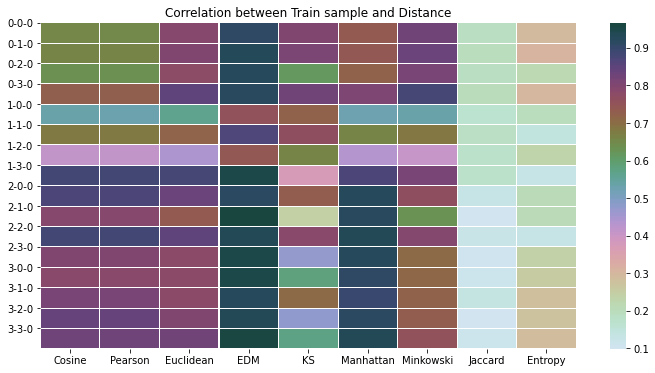

In [10]:
ax = show_heatmap(df_train_set_corr.T)
ticks = ax.set_yticks(range(len(df_train_set_corr.T.index))) # 设置刻度
labels = ax.set_yticklabels(df_train_set_corr.T.index,rotation = 0 ) # 设置刻度标签
ax.set_title("Correlation between Train sample and Distance")

Text(0.5, 1.0, 'Correlation between Train Dataset and Distance')

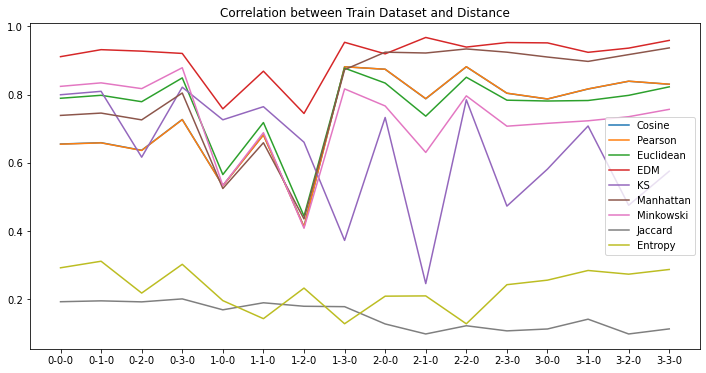

In [11]:
ax = df_train_set_corr.T.plot(kind='line')
ticks = ax.set_xticks(range(len(df_train_set_corr.T.index))) # 设置刻度
labels = ax.set_xticklabels(df_train_set_corr.T.index,rotation = 0 ) # 设置刻度标签
ax.set_title("Correlation between Train Dataset and Distance")

# Detail correlation for each train set

In [12]:
df_group = df_all.groupby("train")
for train_set, df in df_group:
    mask = (df_all.train == train_set)
    df_test = df_all[mask]
    corr = test.Correlation(df_test)
    print("Mean correlation for train set ", train_set)
    display ( corr.mean() )

Mean correlation for train set  0-0-0


Cosine      0.6551
Pearson     0.6546
Euclidean   0.7891
EDM         0.9110
KS          0.7994
Manhattan   0.7389
Minkowski   0.8240
Jaccard     0.1930
Entropy     0.2925
dtype: float64

Mean correlation for train set  0-1-0


Cosine      0.6589
Pearson     0.6585
Euclidean   0.7978
EDM         0.9315
KS          0.8094
Manhattan   0.7457
Minkowski   0.8342
Jaccard     0.1956
Entropy     0.3116
dtype: float64

Mean correlation for train set  0-2-0


...

Cosine      0.8163
Pearson     0.8165
Euclidean   0.7825
EDM         0.9237
KS          0.7079
Manhattan   0.8971
Minkowski   0.7231
Jaccard     0.1419
Entropy     0.2846
dtype: float64

Mean correlation for train set  3-2-0


Cosine      0.8389
Pearson     0.8391
Euclidean   0.7977
EDM         0.9360
KS          0.4757
Manhattan   0.9170
Minkowski   0.7351
Jaccard     0.0986
Entropy     0.2737
dtype: float64

Mean correlation for train set  3-3-0


Cosine      0.8301
Pearson     0.8303
Euclidean   0.8226
EDM         0.9586
KS          0.5755
Manhattan   0.9366
Minkowski   0.7566
Jaccard     0.1135
Entropy     0.2875
dtype: float64

In [13]:
df_group = df_all.groupby("train")
for train_set, df in df_group:
    mask = (df_all.train == train_set)
    df_test = df_all[mask]
    corr = test.Correlation(df_test)
    print("Detail correlation for train set ", train_set)
    display ( corr )

Detail correlation for train set  0-0-0


,Cosine,Pearson,Euclidean,EDM,KS,Manhattan,Minkowski,Jaccard,Entropy
score,,,,,,,,,
recall,0.9197,0.9194,0.9873,0.8740,0.8782,0.9677,0.9965,0.2147,0.3240
accuracy,0.9076,0.9073,0.9823,0.8895,0.8864,0.9594,0.9939,0.2160,0.3238
precision,0.0754,0.0747,0.3018,0.8141,0.5166,0.2069,0.3755,0.1205,0.1872
auc,0.7461,0.7456,0.8846,0.9821,0.8747,0.8349,0.9192,0.2130,0.3136
f1_score,0.6266,0.6260,0.7896,0.9952,0.8411,0.7255,0.8348,0.2010,0.3137


Detail correlation for train set  0-1-0


,Cosine,Pearson,Euclidean,EDM,KS,Manhattan,Minkowski,Jaccard,Entropy
score,,,,,,,,,
recall,0.8989,0.8986,0.9783,0.9017,0.8961,0.9535,0.9917,0.2164,0.3604
accuracy,0.8445,0.8441,0.9488,0.9460,0.8974,0.9131,0.9711,0.2166,0.3569
precision,0.1653,0.1645,0.3877,0.8618,0.5572,0.2959,0.4587,0.1354,0.1856
auc,0.8223,0.8219,0.9355,0.9570,0.8928,0.8965,0.9609,0.2163,0.3501
f1_score,0.5638,0.5632,0.7388,0.9910,0.8036,0.6695,0.7888,0.1934,0.3053


Detail correlation for train set  0-2-0


...

,Cosine,Pearson,Euclidean,EDM,KS,Manhattan,Minkowski,Jaccard,Entropy
score,,,,,,,,,
recall,0.8846,0.8848,0.8449,0.9942,0.7434,0.9687,0.7781,0.1003,0.2889
accuracy,0.9419,0.9419,0.9337,0.8492,0.8132,0.9226,0.8894,0.1979,0.4349
precision,0.5338,0.5342,0.4858,0.8279,0.5102,0.7028,0.4258,0.1299,0.1242
auc,0.9261,0.9263,0.8983,0.9656,0.7748,0.9749,0.8394,0.1589,0.3303
f1_score,0.7951,0.7954,0.7501,0.9818,0.6978,0.9166,0.6826,0.1225,0.2446


Detail correlation for train set  3-2-0


,Cosine,Pearson,Euclidean,EDM,KS,Manhattan,Minkowski,Jaccard,Entropy
score,,,,,,,,,
recall,0.7498,0.7501,0.6984,0.9571,0.2890,0.8826,0.6294,0.0852,0.1973
accuracy,0.9664,0.9664,0.9374,0.9433,0.7294,0.9849,0.8800,0.1324,0.3663
precision,0.7690,0.7693,0.7179,0.9509,0.2852,0.8903,0.6509,0.0654,0.2236
auc,0.9718,0.9718,0.9486,0.8771,0.8097,0.9537,0.8979,0.1295,0.3864
f1_score,0.7377,0.7380,0.6860,0.9517,0.2650,0.8737,0.6173,0.0803,0.1951


Detail correlation for train set  3-3-0


,Cosine,Pearson,Euclidean,EDM,KS,Manhattan,Minkowski,Jaccard,Entropy
score,,,,,,,,,
recall,0.8599,0.8601,0.8514,0.9925,0.5958,0.9699,0.7829,0.1173,0.2973
accuracy,0.9732,0.9733,0.9666,0.8882,0.8592,0.9700,0.9119,0.1418,0.3564
precision,0.6306,0.6310,0.6235,0.9393,0.2717,0.8261,0.5537,0.0797,0.2047
auc,0.8974,0.8976,0.8901,0.9839,0.6657,0.9841,0.8237,0.1237,0.3108
f1_score,0.7895,0.7898,0.7812,0.9892,0.4849,0.9329,0.7110,0.1048,0.2684


# Distribution by Score and distance

In [14]:
def get_distribution( df, metric = "EDM", degree = 9 ):
    df_test = df[[metric,'train','valid','recall', 'accuracy', 'precision', 'auc', 'f1_score']]
    df_test[metric] = ( df_test[metric] - df_test[metric].mean() ) / ( df_test[metric].max()-df_test[metric].min() ) 
    df_t = df_test.sort_values(by=metric)
    for key in [metric,'recall', 'accuracy', 'precision', 'auc', 'f1_score']:
        if not key in df_t.keys() and key != metric:
            continue
        cate = pd.qcut( df_t[key], degree, labels=False, duplicates='drop', precision=8)
        cate.fillna(-1,inplace=True)
        df_t[key] = cate
    df_dis = pd.DataFrame()
    all_data = []
    for d,df in df_t.groupby(metric):
        del df['train']
        del df['valid']
        del df[metric]
        pd_keys = df.keys()
        pd_keys.sort_values()
        for item in pd_keys:
            tmp = {}
            tmp['Distance'] = d
            tmp['Score'] = item
            jdata = json.loads(df[item].value_counts().to_json())
            json_keys = list(jdata.keys())
            json_keys.sort()
            for key in json_keys:
                value = jdata[key]
                tmp["score-%s"%key] = int(value)
            all_data.append( tmp )
    df_dis = pd.DataFrame(all_data).fillna(0)
    for i in range(len(df_t[metric].unique())):
        key = "score-%d"%i
        df_dis[key] = df_dis[key].astype(int)
    return df_dis

In [15]:
df_dis = get_distribution(df_all ,metric = 'EDM', degree = 5 )
df_dis.groupby(["Distance"]).sum().T.sort_index().T

,score-0,score-1,score-2,score-3,score-4
Distance,,,,,
0,0,4,76,261,684
1,2,17,225,518,263
2,10,328,470,154,58
3,278,418,217,92,20
4,735,258,32,0,0


score-0                                 score-1               \
Score    accuracy  auc f1_score precision recall accuracy auc f1_score   
Distance                                                                 
0               0    0        0         0      0        0   4        0   
1               0    2        0         0      0        4   8        0   
2              10    0        0         0      0       56  55       64   
3              82   68       37        38     53       69  68      104   
4             113  135      168       167    152       76  70       37   

                           score-2                                 score-3  \
Score    precision recall accuracy  auc f1_score precision recall accuracy   
Distance                                                                     
0                0      0        0    9        0        44     23       43   
1                1      4       18   19       40        94     54      140   
2               99     54      127  133      104        18     88       11   
3               83     94       43   43       60        32     39       11   
4               22     53       16    0        0        16      0        0   

                                         score-4                          \
Score     auc f1_score precision recall accuracy  auc f1_score precision   
Distance                                                                   
0          33       49        55     81      162  159      156       106   
1         130      116        45     87       43   46       49        65   
2          16       36        73     18        0    0        0        14   
3          26        4        32     19        0    0        0        20   
4           0        0         0      0        0    0        0         0   

                 
Score    recall  
Distance         
0           101  
1            60  
2            44  
3             0  
4             0

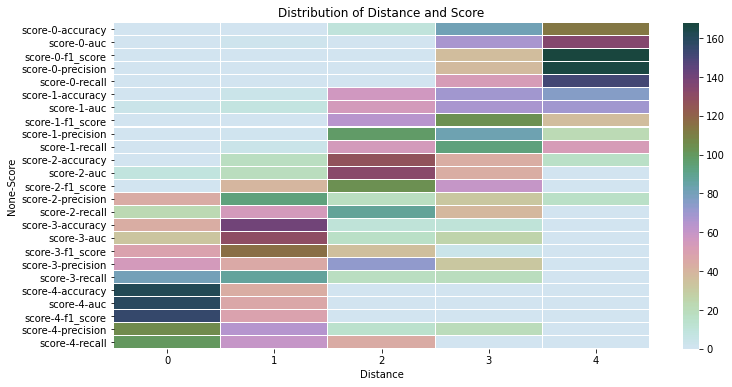

In [17]:
pt = df_dis.pivot_table(index='Distance', columns=['Score'] ,aggfunc=np.sum)
ax = show_heatmap(pt.T)
ax.set_title("Distribution of Distance and Score")
pt